<a href="https://colab.research.google.com/github/toryor31oct/group15-Fun-Rai-Kwam-plod-Phai/blob/Nam-ing/graph2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd

In [ ]:
# 1. ติดตั้งฟอนต์ภาษาไทย (สำหรับ Linux/Colab)
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

# 5. ข้อมูล Q2 (Approved vs Rejected)
status_df = pd.DataFrame({
    'claim_status': ['Approved', 'Rejected'],
    'case_count': [276, 24],
    'net_paid_millions': [265.93, 0.00]
})

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

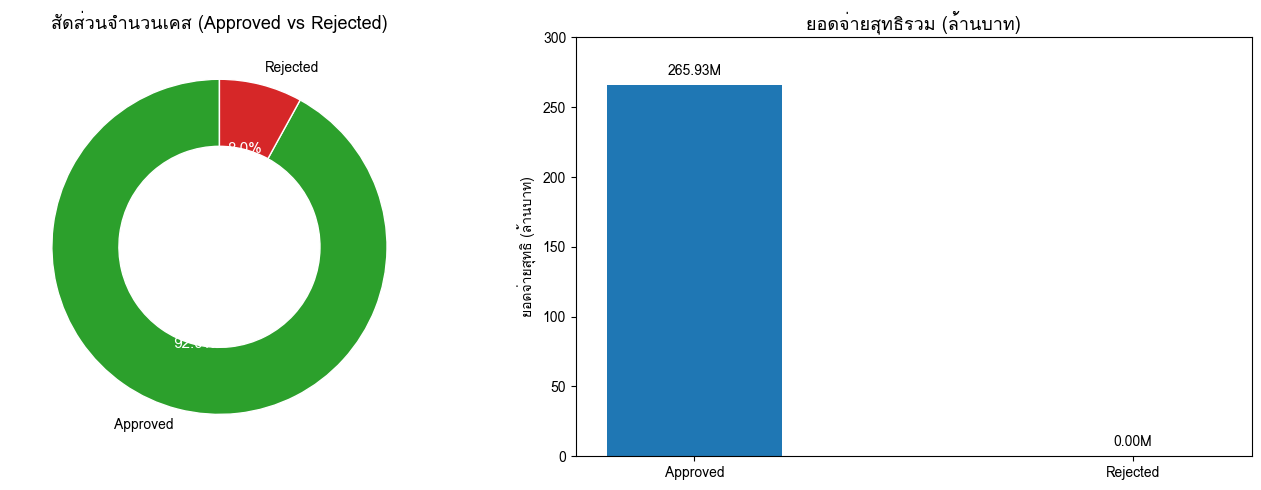

In [ ]:
#กราฟภาพรวมสถานะการอนุมัติ (Approved vs Rejected) และ จำนวนกี่เคส
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# สัดส่วนจำนวนเคส
colors_donut = ['#2ca02c', '#d62728']

wedges, texts, autotexts = axes[0].pie(
    status_df['case_count'],
    labels=status_df['claim_status'],
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_donut,
    wedgeprops=dict(width=0.4, edgecolor='w')
)
axes[0].set_title("สัดส่วนจำนวนเคส (Approved vs Rejected)", fontsize=13, fontweight='bold')

for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_color('white')
    autotext.set_weight('bold')

# ยอดจ่ายสุทธิรวม
colors_bar = ['#1f77b4', '#ff7f0e']

bars = axes[1].bar(
    status_df['claim_status'],
    status_df['net_paid_millions'],
    color=colors_bar,
    width=0.4
)
axes[1].set_title("ยอดจ่ายสุทธิรวม (ล้านบาท)", fontsize=13, fontweight='bold')
axes[1].set_ylabel("ยอดจ่ายสุทธิ (ล้านบาท)")
axes[1].set_ylim(0, 300)

for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2.0,
        height + 5,
        f'{height:.2f}M',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()